> **Superseded for production use, 2026-08-30.**
>
> This notebook builds the FD001-only baseline and is kept as the comparison
> point and as the record of how the module started. The model that feeds the
> Quality Steering Cell is now trained on all four CMAPSS subsets with temporal
> features, by `notebooks/01_timeseries/cmapss_full_fleet.py`.
>
> Three things here were measured to be wrong or incomplete once the full fleet
> was used, and they are worth reading before reusing anything from this file:
>
> 1. `cycle` is dropped from the features. It is a strong predictor of remaining
>    life and removing it cost about 1.7 RMSE.
> 2. The flat-sensor list is derived from FD001 alone. `s6`, `s10` and `s16` are
>    constant here but carry signal across the fleet.
> 3. There are no temporal features at all, so the model sees one snapshot at a
>    time. Adding rolling statistics over a 20-cycle window was worth 5.3 RMSE,
>    the single largest improvement in the module.
>
> Figures and the full decomposition: `docs/Model_Card_CMAPSS_RUL.md`.


# CMAPSS - Preprocessing & Feature Engineering
**Arkon Manufacturing AI | Module: Time Series | Department: Engine Testing**

**Goal:** Transform raw sensor data into a clean, model-ready dataset.

Steps:
1. Add RUL (Remaining Useful Life) as target column
2. Drop flat (zero-variance) sensors
3. Normalise sensor readings
4. Save processed train/test sets

In [1]:
import sys
from pathlib import Path

# Add notebooks/utils to path (works on Mac, Windows, Linux)
_nb_root = Path('..').resolve()
if str(_nb_root) not in sys.path:
    sys.path.insert(0, str(_nb_root))

from utils.arkon_utils import (
    get_device, get_mlflow_uri, save_figure,
    Timer, CheckpointManager, recommended_num_workers
)

print('arkon_utils loaded ✓')

arkon_utils loaded ✓


## 1. Imports & Configuration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
import joblib

plt.style.use('seaborn-v0_8-darkgrid')
ASSETS = 'timeseries'

# Paths
RAW_DIR  = Path('../../data/01_cmapss/raw/CMaps')
PROC_DIR = Path('../../data/01_cmapss/processed')
PROC_DIR.mkdir(parents=True, exist_ok=True)

# Column names - CMAPSS files have no header row
COLUMNS = [
    'unit', 'cycle',
    'os_1', 'os_2', 'os_3',
    's1',  's2',  's3',  's4',  's5',  's6',  's7',
    's8',  's9',  's10', 's11', 's12', 's13', 's14',
    's15', 's16', 's17', 's18', 's19', 's20', 's21'
]

# Flat sensors identified in 01_cmapss_eda.ipynb - carry no signal
DROP_SENSORS = ['s1', 's5', 's6', 's10', 's16', 's18', 's19']

## 2. Load Raw Data

In [3]:
# Load FD001 train and test sets from raw txt files
df_train = pd.read_csv(RAW_DIR / 'train_FD001.txt', sep=r'\s+', header=None, names=COLUMNS)
df_test  = pd.read_csv(RAW_DIR / 'test_FD001.txt',  sep=r'\s+', header=None, names=COLUMNS)
df_rul   = pd.read_csv(RAW_DIR / 'RUL_FD001.txt',   header=None, names=['RUL'])

print(f'Train: {df_train.shape} | Test: {df_test.shape} | RUL: {df_rul.shape}')

Train: (20631, 26) | Test: (13096, 26) | RUL: (100, 1)


## 3. Add RUL to Training Set

In [4]:
# Calculate RUL for each row: RUL = max_cycle_of_engine - current_cycle
# In training set every engine ran to failure, so max_cycle = time of failure
max_cycles = df_train.groupby('unit')['cycle'].max().reset_index()
max_cycles.columns = ['unit', 'max_cycle']

df_train = df_train.merge(max_cycles, on='unit')
df_train['RUL'] = df_train['max_cycle'] - df_train['cycle']
df_train.drop(columns=['max_cycle'], inplace=True)

print('RUL added. Sample values:')
print(df_train[['unit', 'cycle', 'RUL']].head(10))

RUL added. Sample values:
   unit  cycle  RUL
0     1      1  191
1     1      2  190
2     1      3  189
3     1      4  188
4     1      5  187
5     1      6  186
6     1      7  185
7     1      8  184
8     1      9  183
9     1     10  182


## 4. Cap RUL (Piecewise Linear Degradation)

RUL capped at 125. New max RUL: 125


  ✓ Saved → assets\timeseries\cmapss_preprocessing_rul_distribution.png


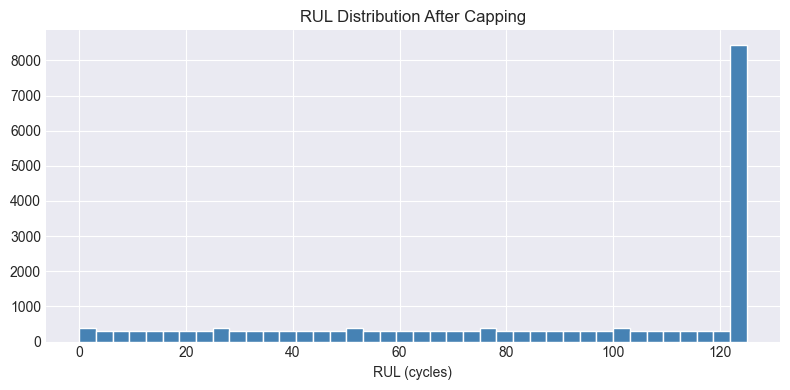

In [5]:
# Cap maximum RUL at 125 - engines don't degrade meaningfully in early cycles
# This is standard practice in CMAPSS literature (piecewise linear RUL)
RUL_CAP = 125
df_train['RUL'] = df_train['RUL'].clip(upper=RUL_CAP)

print(f'RUL capped at {RUL_CAP}. New max RUL: {df_train["RUL"].max()}')

# Visualise effect of capping on RUL distribution
fig, ax = plt.subplots(figsize=(8, 4))
df_train['RUL'].hist(bins=40, color='steelblue', edgecolor='white', ax=ax)
ax.set_xlabel('RUL (cycles)')
ax.set_title('RUL Distribution After Capping')
plt.tight_layout()
save_figure(fig, 'cmapss_preprocessing_rul_distribution', subfolder=ASSETS)
plt.show()

## 5. Add RUL to Test Set

In [6]:
# For test set: RUL at last cycle of each engine = value from RUL_FD001.txt
# Add the true RUL to the last row of each test engine
last_cycles = df_test.groupby('unit')['cycle'].max().reset_index()
last_cycles.columns = ['unit', 'max_cycle']
last_cycles['RUL'] = df_rul['RUL'].values

df_test = df_test.merge(last_cycles[['unit', 'max_cycle', 'RUL']], on='unit')

# Compute RUL for all rows in test set (not just last cycle)
df_test['RUL'] = df_test['RUL'] + (df_test['max_cycle'] - df_test['cycle'])
df_test['RUL'] = df_test['RUL'].clip(upper=RUL_CAP)
df_test.drop(columns=['max_cycle'], inplace=True)

print(f'Test set with RUL: {df_test.shape}')

Test set with RUL: (13096, 27)


## 6. Drop Flat Sensors

In [7]:
# Remove sensors with near-zero variance - they contain no information for the model
df_train.drop(columns=DROP_SENSORS, inplace=True)
df_test.drop(columns=DROP_SENSORS, inplace=True)

print(f'Columns after dropping flat sensors: {df_train.shape[1]}')
print(f'Remaining columns: {list(df_train.columns)}')

Columns after dropping flat sensors: 20
Remaining columns: ['unit', 'cycle', 'os_1', 'os_2', 'os_3', 's2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21', 'RUL']


## 7. Normalise Sensor Readings

In [8]:
# Normalise all sensor and operating setting columns to [0, 1] range
# Scaler is fit on train set ONLY - then applied to test set (no data leakage)
feature_cols = [c for c in df_train.columns if c not in ['unit', 'cycle', 'RUL']]

scaler = MinMaxScaler()
df_train[feature_cols] = scaler.fit_transform(df_train[feature_cols])
df_test[feature_cols]  = scaler.transform(df_test[feature_cols])

# Save scaler so we can use it in the Streamlit app without refitting
joblib.dump(scaler, PROC_DIR / 'scaler_FD001.pkl')
print(f'Scaler saved. Features normalised: {feature_cols}')

Scaler saved. Features normalised: ['os_1', 'os_2', 'os_3', 's2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']


## 8. Save Processed Data

In [9]:
# Save processed train and test sets as CSV for use in modeling notebook
df_train.to_csv(PROC_DIR / 'train_FD001_processed.csv', index=False)
df_test.to_csv(PROC_DIR  / 'test_FD001_processed.csv',  index=False)

print('Saved:')
print(f'  train_FD001_processed.csv - {df_train.shape}')
print(f'  test_FD001_processed.csv  - {df_test.shape}')

Saved:
  train_FD001_processed.csv - (20631, 20)
  test_FD001_processed.csv  - (13096, 20)


## 9. Summary

| Step | Action | Result |
|------|--------|--------|
| RUL label | max_cycle − current_cycle | Target column added |
| RUL cap | clip at 125 | Piecewise linear degradation |
| Drop sensors | s1, s5, s6, s10, s16, s18, s19 | 7 useless columns removed |
| Normalise | MinMaxScaler fit on train | All features in [0, 1] |
| Save | CSV + scaler pkl | Ready for modeling |

**Next step:** `03_cmapss_modeling.ipynb` - train XGBoost RUL model with MLflow tracking.